### Import

In [1]:
from sklearn.metrics import  f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import warnings

import mlflow
import os




### Constant

In [2]:
DATAPATH = "../../data/data.pkl"
EXP_NAME = "fraud_detection"
MODEL_NAME = "fraud_detector"
MLFLOW_URI = "http://127.0.0.1:5000/"
MLFLOW_DB = "sqlite:///../../data/mlflow/fraud_detection.db"
ARTIFACT_PATH = f"file://{os.path.abspath('../../data/mlflow/artifacts')}"
RANDOM_STATE = 42

### Read Data

In [3]:
df = pd.read_pickle(DATAPATH)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1777056,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,0
1350600,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,0
1991933,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,0
5092368,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,0
5066515,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,0


### EDA

In [4]:
# What are the different type of transactions ?
df.type.value_counts()

type
CASH_OUT    10840
PAYMENT      6443
TRANSFER     5655
CASH_IN      4227
DEBIT         111
Name: count, dtype: int64

In [5]:
# Target porportion
df.isFraud.value_counts(normalize=True)

isFraud
0    0.698893
1    0.301107
Name: proportion, dtype: float64

In [6]:
# Fraud per type of transactions
df[df.isFraud == 1].type.value_counts(normalize=True)

type
CASH_OUT    0.501157
TRANSFER    0.498843
Name: proportion, dtype: float64

#### Preprocess

In [7]:
def wrangle(df):
    df = df.copy()

    cols = []

    # Features leakage
    cols.append("newbalanceDest")
    cols.append("newbalanceOrig")

    # transform step into time
    df["time"] = df["step"].apply(lambda step: (step - 1) % 24 + 1)
    cols.append("step")

    # System Flag
    cols.append("isFlaggedFraud")

    # keep only type of customers M or C
    df["nameOrig"] = df["nameOrig"].str[0]
    df["nameDest"] = df["nameDest"].str[0]
    

    df.drop(columns=cols, inplace=True)
    return df


In [8]:
df_preprocessed = wrangle(df)

### Model

In [9]:
target = "isFraud"
X = df.drop(columns=[target])
y = df[target]

In [10]:
cat_cols = df.select_dtypes("object").columns.tolist()

/var/folders/q0/tlxqcyzj4bl5486b7j7s6ymw0000gn/T/ipykernel_4709/2502784212.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes("object").columns.tolist()


In [11]:
# Split data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

#### Setup Tracking server

In [12]:
mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.create_experiment(EXP_NAME, artifact_location=ARTIFACT_PATH)
mlflow.set_experiment(EXP_NAME)

2026/05/26 00:34:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/26 00:34:44 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///Users/serge-nd/IdeaProjects/DSA/data/mlflow/artifacts', creation_time=1779748484803, experiment_id='1', last_update_time=1779748484803, lifecycle_stage='active', name='fraud_detection', tags={}, workspace='default'>

In [22]:
def tracking_expirement(run_name, model_name, pipe, X_test, X_train):
    with mlflow.start_run(run_name=run_name):
        
        target_names = ["is_not_fraud", "is_fraud"]

        # ***************Log dataset**************************
        
        test_dataset = mlflow.data.from_pandas(X_test)
        mlflow.log_input(dataset=test_dataset, context="test")

        train_dataset = mlflow.data.from_pandas(X_train)
        mlflow.log_input(dataset=train_dataset, context="train")

        pipe.fit(X_train, y_train)

        # *************** Log metrics **************************

        accurary = pipe.score(X_train, y_train)
        f1_metric = f1_score(y_train, pipe.predict(X_train))

        accurary_test = pipe.score(X_test, y_test)
        f1_metric_test = f1_score(y_test, pipe.predict(X_test))

        mlflow.log_metrics({
            "accuracy_train": round(accurary, 2),
            "f1_score_train": round(f1_metric,2) ,
            "accuracy_test": round(accurary_test,2),
            "f1_score_test": round(f1_metric_test,2)
        })

        # *************** Log model **************************

        mlflow.sklearn.log_model(pipe, name=model_name)

        cm = confusion_matrix(y_true=y_test, y_pred=pipe.predict(X_test))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=target_names)
        disp.plot()

        # *************** Log figure **************************

        mlflow.log_figure(disp.figure_, f"confusion_matrix_{model_name}.png")

#### Baseline

In [14]:
# Target porportion
df.isFraud.value_counts(normalize=True)

isFraud
0    0.698893
1    0.301107
Name: proportion, dtype: float64

#### Random Forest

##### Build

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"  # keeps numeric columns as-is
)

rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier()
)

##### Iterate

/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing val

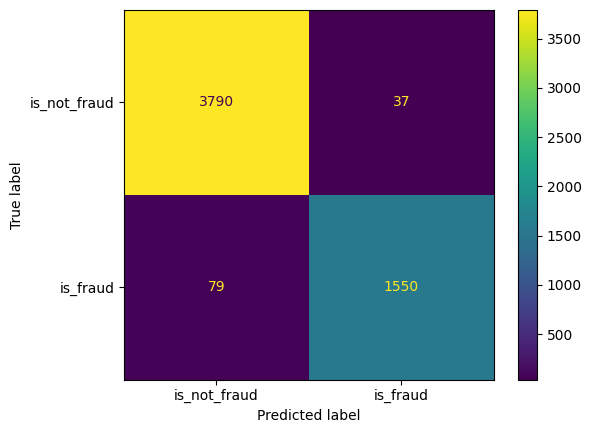

In [23]:
run_name = "random_forest"

tracking_expirement(run_name, MODEL_NAME, rf_pipe, X_train=X_train, X_test=X_test)

##### Evaluate

In [57]:
y_pred = rf_pipe.predict(X_train)
y_pred_test = rf_pipe.predict(X_test)

In [58]:
train_score = rf_pipe.score(X_train, y_train)
test_score = rf_pipe.score(X_test, y_test)
f1_score_test = f1_score(y_test, y_pred_test)
f1_score_train = f1_score(y_train, y_pred)
print("Training score", train_score)
print("Test score", test_score)
print("F1 score test", f1_score_test)
print("F1 score training", f1_score_train)

Training score 1.0
Test score 0.9776392961876833
F1 score test 0.9621353196772191
F1 score training 1.0


In [60]:
target_names = ["is_not_fraud", "is_fraud"]
print(classification_report(y_true=y_test, y_pred=y_pred_test, target_names=target_names))

              precision    recall  f1-score   support

is_not_fraud       0.98      0.99      0.98      3827
    is_fraud       0.97      0.95      0.96      1629

    accuracy                           0.98      5456
   macro avg       0.98      0.97      0.97      5456
weighted avg       0.98      0.98      0.98      5456



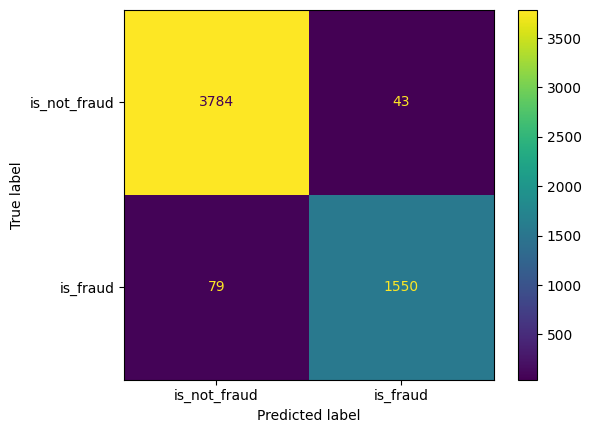

In [63]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot()

#### Xgboost

##### Build

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"  # keeps numeric columns as-is
)

xg_pipe = make_pipeline(
    preprocessor,
    XGBClassifier()
)

##### Iterate

In [67]:
xg_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

##### Evaluate

In [71]:
y_pred_xg = xg_pipe.predict(X_train)
y_pred_test_xg = xg_pipe.predict(X_test)

In [72]:
train_score = xg_pipe.score(X_train, y_train)
test_score = xg_pipe.score(X_test, y_test)
f1_score_test = f1_score(y_test, y_pred_test_xg)
f1_score_train = f1_score(y_train, y_pred_xg)
print("Training score", train_score)
print("Test score", test_score)
print("F1 score test", f1_score_test)
print("F1 score training", f1_score_train)

Training score 0.9994958753437213
Test score 0.9948680351906158
F1 score test 0.9914477703115455
F1 score training 0.9991645781119465


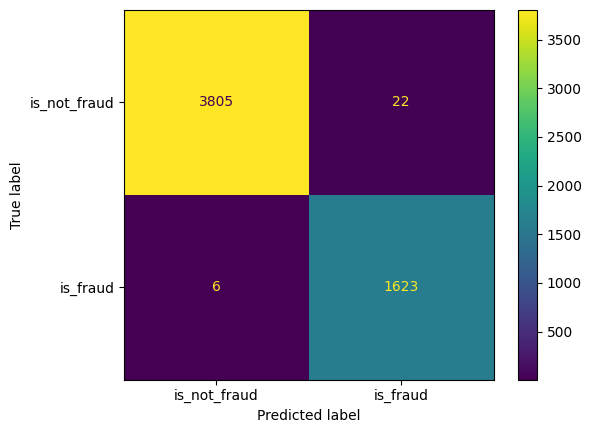

In [73]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred_test_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot()

/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing val

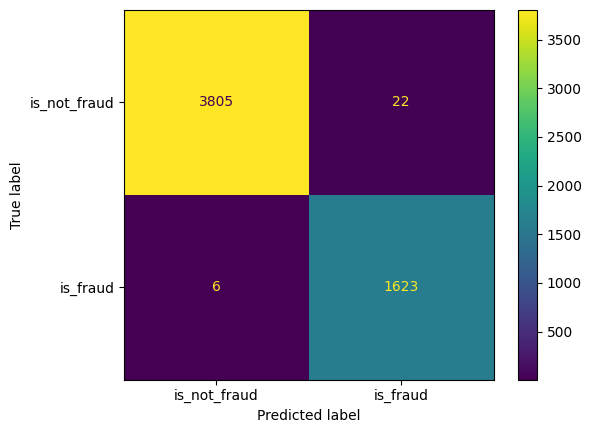

In [24]:
run_name = "xgboost"

tracking_expirement(run_name, MODEL_NAME, xg_pipe, X_train=X_train, X_test=X_test)

### Register the best model

In [ ]:
def register_best_model(experiment_name, model_name):
    
    # Get experiment by name
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found")

    # Search all runs in the experiment, ordered by f1_score_test descending
    best_run = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["metrics.f1_score_test DESC"],
        max_results=1
    )

    if best_run.empty:
        raise ValueError(f"No runs found in experiment '{experiment_name}'")

    best_run_id = best_run.iloc[0]["run_id"]
    best_run_name = best_run.iloc[0]["tags.mlflow.runName"]
    best_f1    = best_run.iloc[0]["metrics.f1_score_test"]

    print(f"Best run ID : {best_run_id}")
    print(f"Best F1 test: {best_f1:.4f}")

    # Register the model from the best run
    model_uri = f"runs:/{best_run_id}/{model_name}"
    registered = mlflow.register_model(model_uri=model_uri, name=model_name)

    client = mlflow.tracking.MlflowClient()
    client.set_model_version_tag(
        name=model_name,
        version=registered.version,
        key="run_name",
        value=best_run_name
    )

    print(f"Model '{model_name}' registered — version {registered.version}")
    print(f"Tagged with run_name: {best_run_name}")
    return registered


    print(f"Model '{model_name}' registered — version {registered.version}")
    return registered

In [30]:
register_best_model(
    experiment_name=EXP_NAME,
    model_name=MODEL_NAME
)

Registered model 'fraud_detector' already exists. Creating a new version of this model...
2026/05/26 00:45:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 2f7adef3c5684eacb94eb91f43ae46bb has no artifacts at artifact path 'fraud_detector', registering model based on models:/m-baaa8cda2c3a4e1ba4a73efe1b73b5f7 instead


Best run ID : 2f7adef3c5684eacb94eb91f43ae46bb
Best F1 test: 0.9900
Model 'fraud_detector' registered — version 2
Tagged with run_name: xgboost


Created version '2' of model 'fraud_detector'.


<ModelVersion: aliases=[], creation_timestamp=1779749157771, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1779749157771, metrics=None, model_id=None, name='fraud_detector', params=None, run_id='2f7adef3c5684eacb94eb91f43ae46bb', run_link=None, source='models:/m-baaa8cda2c3a4e1ba4a73efe1b73b5f7', status='READY', status_message=None, tags={}, user_id=None, version=2, workspace='default'>